# Summary

## Goal

We can think of the final mode choice in a random utility framework as:

$$
U_{im}
= \beta_{\text{time}} \cdot \mathbb{E}[\text{TT}_{im}]
+ \beta_{\text{uncert}} \cdot \text{SD}(\text{TT}_{im})
+ \beta_{\text{cost}} \cdot \text{Cost}_{im}
+ \varepsilon_{im}
$$

Where:

- $i$  
  - Index for the individual (agent).

- $m$  
  - Index for the mode (e.g., car, bus).

- $U_{im}$  
  - Latent utility (or negative generalized disutility) that individual $i$ associates with mode $m$.

- $\mathbb{E}[\text{TT}_{im}]$  
  - Expected travel time for individual $i$ using mode $m$ (e.g., in minutes), coming from their belief/learning process.

- $\text{SD}(\text{TT}_{im})$  
  - Standard deviation (uncertainty) of travel time for individual $i$ using mode $m$, also derived from beliefs.

- $\text{Cost}_{im}$  
  - Monetary cost associated with using mode $m$ for individual $i$ (e.g., tolls, fares, etc.).

- $\beta_{\text{time}}$  
  - Coefficient measuring marginal (dis)utility per unit of expected travel time.

- $\beta_{\text{uncert}}$  
  - Coefficient measuring marginal (dis)utility per unit of travel time uncertainty.

- $\beta_{\text{cost}}$  
  - Coefficient measuring marginal (dis)utility per unit of monetary cost.

- $\varepsilon_{im}$  
  - Random taste shock capturing unobserved factors; in a logit model this would typically be i.i.d. Gumbel.





## Units summary for the belief and utility functions

### 1. `compute_experience_beliefs`

**Inputs (conceptual units):**
- `travel_data`: sequence of `(day, travel_time)`
  - `day_i`: dimensionless day index (e.g. 0, 1, 2, …)
  - `travel_time_i`: **minutes**
- `current_day`: same units as `day_i` (dimensionless day index)
- `time_decay_rate`: **per day** (e.g. 0.1 / day in an exponential decay)
- `travel_time_prior`: **minutes**
- `prior_weight`: dimensionless (pseudo-count / effective weight)

**Outputs:**
- `expected_travel_time`: **minutes**  
- `travel_time_uncertainty`: **minutes**  
  (interpreted as the standard deviation of the belief about travel time)

---

### 2. `compute_generalized_cost`

**Inputs (conceptual units):**
- `expected_travel_time`: **minutes**  
  - Belief about mean travel time for this mode on this day.
- `travel_time_uncertainty`: **minutes**  
  - Belief about uncertainty in travel time (e.g., standard deviation).
- `uncertainty_multiplier`: dimensionless  
  - Scales how much uncertainty contributes to “effective minutes” (can be positive, negative, or zero).
- `value_of_time`: **money per minute** (e.g. dollars/minute)  
  - Converts effective minutes into monetary units.
- `experience_weight`: dimensionless  
  - Mode-/agent-specific factor (λₘ) that rescales perceived minutes in this mode.
- `toll`: **money** (e.g. dollars)  
  - Monetary toll or fare for this mode on this day.

**Outputs:**
- `generalized_cost`: **money**  
  - Total generalized cost $C_m(t)$ in monetary units; this is the quantity compared across modes (choose the mode with lower `generalized_cost`).


In [75]:
from math import exp, sqrt
from typing import Sequence, Tuple
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from itertools import product

import numpy as np
from scipy.stats import lognorm


# step one: compute expected value and variance of future outcomes given current beliefs

In [ ]:


def compute_experience_beliefs(
    travel_data: Sequence[Tuple[float, float]],
    current_day: float,
    time_decay_rate: float,
    travel_time_prior: float,
    prior_weight: float = 1.0,
) -> Tuple[float, float]:
    """
    Compute decay-weighted beliefs about travel time from past trip history.


    Parameters
    ----------
    travel_data : sequence of (day, travel_time)
        History of realized travel times for this agent and mode.
        Each element is a tuple (day_i, travel_time_i), with day_i <= current_day.
    current_day : float
        The day index at which beliefs are being evaluated (e.g., t in U_m(t)).
    time_decay_rate : float
        Exponential decay rate λ >= 0. Larger values mean older trips lose weight faster.
    travel_time_prior : float
        Prior mean travel time to which expected_travel_time will revert as the
        influence of past data decays away.
    prior_weight : float, default 1.0
        Effective weight of the prior in the weighted average. Acts like a pseudo-count:
        larger values keep beliefs closer to travel_time_prior.

    Returns
    -------
    expected_travel_time : float
        Decay-weighted mean travel time at current_day, shrunk toward travel_time_prior.
    travel_time_uncertainty : float
        A measure of uncertainty about the mean travel time, increasing as the total
        effective weight (prior_weight + W(t)) becomes small (e.g., when the mode
        hasn’t been used recently or often).
    """
    # No data at all: fall back to prior and a simple uncertainty proxy
    if not travel_data:
        expected_travel_time = travel_time_prior
        # Maximal uncertainty case; you can refine this later if you like.
        travel_time_uncertainty = 1.0 / max(prior_weight, 1e-8)
        return expected_travel_time, travel_time_uncertainty

    # Exponential decay weights based on how long ago each trip was
    weights = []
    times = []
    for day_i, travel_time_i in travel_data:
        age = current_day - day_i
        w_i = exp(-time_decay_rate * age) if time_decay_rate > 0 else 1.0
        weights.append(w_i)
        times.append(travel_time_i)

    W = sum(weights)

    # Decay-weighted mean with prior pull
    total_weight = prior_weight + W
    weighted_sum = prior_weight * travel_time_prior + sum(w * y for w, y in zip(weights, times))
    expected_travel_time = weighted_sum / total_weight

    # Decay-weighted squared deviations (including the prior as a pseudo-observation)
    S = prior_weight * (travel_time_prior - expected_travel_time) ** 2
    S += sum(w * (y - expected_travel_time) ** 2 for w, y in zip(weights, times))

    # Treat total_weight as an "effective sample size" to scale uncertainty:
    # more total weight -> smaller uncertainty; as weights decay, uncertainty grows.
    travel_time_uncertainty = sqrt(S) / total_weight if total_weight > 0 else 0.0

    return expected_travel_time, travel_time_uncertainty


# step two: compute utility of mode based on beliefs and preferences

In [7]:
def compute_generalized_cost(
    expected_travel_time: float,
    travel_time_uncertainty: float,
    uncertainty_multiplier: float,
    value_of_time: float,
    experience_weight: float,
    toll: float = 0.0,
) -> float:
    """
    Compute generalized monetary cost for a mode from experience-based beliefs and a toll.

    Parameters
    ----------
    expected_travel_time : float
        Belief about mean travel time for this mode on this day (e.g., minutes).
    travel_time_uncertainty : float
        Belief about uncertainty in travel time (e.g., standard deviation, minutes).
    uncertainty_multiplier : float
        Scalar controlling how uncertainty contributes to the effective minutes:
          > 0 : uncertainty makes the mode worse (adds effective minutes).
          < 0 : uncertainty makes the mode better (subtracts effective minutes).
          = 0 : uncertainty ignored.
    value_of_time : float
        Monetary value per minute of effective travel time (e.g., dollars per minute).
    experience_weight : float
        Mode-/agent-specific weight λ_m that rescales perceived minutes in this mode:
          > 1 : minutes in this mode feel worse than baseline.
          < 1 : minutes in this mode feel better than baseline.
          = 1 : neutral.
    toll : float, default 0.0
        Monetary toll or fare for this mode on this day (e.g., dollars).

    Returns
    -------
    float
        Generalized cost C_m(t) in money units (e.g., dollars).
    """
    effictive_mins = expected_travel_time + (uncertainty_multiplier * travel_time_uncertainty) # Effective minutes from beliefs
    travel_time_cost = value_of_time * experience_weight * effictive_mins # Monetary equivalent of effective minutes
    generalized_cost =  travel_time_cost + toll
    return generalized_cost


# fake person agent

In [ ]:

class LightweightPerson:
    def __init__(
        self,
        person_id,
        prior_car=40.0,
        prior_bus=40.0,
        value_of_time=30.0,  # dollars per hour
        experience_weight_car=1.0,
        experience_weight_bus=1.0,
        uncertainty_multiplier=0.0,
        time_decay_rate=0.1,
        prior_weight=1.0,
    ):
        self.person_id = person_id

        # priors (can set equal so beliefs_bus = beliefs_car initially)
        self.prior_car = prior_car
        self.prior_bus = prior_bus

        # preferences / parameters
        self.value_of_time = value_of_time/60 # convert to $/min
        self.experience_weight_car = experience_weight_car
        self.experience_weight_bus = experience_weight_bus
        self.uncertainty_multiplier = uncertainty_multiplier
        self.time_decay_rate = time_decay_rate
        self.prior_weight = prior_weight

        # raw histories: list of (day, travel_time)
        self.history_car = []
        self.history_bus = []

    def get_beliefs(self, mode, day):
        if mode == "car":
            history = self.history_car
            prior = self.prior_car
        else:  # "bus"
            history = self.history_bus
            prior = self.prior_bus

        expected_tt, uncertainty_tt = compute_experience_beliefs(
            travel_data=history,
            current_day=day,
            time_decay_rate=self.time_decay_rate,
            travel_time_prior=prior,
            prior_weight=self.prior_weight,
        )
        return expected_tt, uncertainty_tt

    def compute_cost(self, mode, day, toll):
        expected_tt, uncertainty_tt = self.get_beliefs(mode, day)

        if mode == "car":
            experience_weight = self.experience_weight_car
        else:  # "bus"
            experience_weight = self.experience_weight_bus

        return compute_generalized_cost(
            expected_travel_time=expected_tt,
            travel_time_uncertainty=uncertainty_tt,
            uncertainty_multiplier=self.uncertainty_multiplier,
            value_of_time=self.value_of_time,
            experience_weight=experience_weight,
            toll=toll,
        )

    def decide_mode(self, day, toll_car=0.0, toll_bus=0.0):
        cost_car = self.compute_cost("car", day, toll_car)
        cost_bus = self.compute_cost("bus", day, toll_bus)
        # True = take_car, False = take_bus
        return cost_car < cost_bus


# -`-`-`-`-`-`-`-`-`-FROM HERE DOWN IS NOT FOR THE AGENT -`-`-`-`-`-`-`-`-`-
    def update_history(self, day, mode, realized_travel_time):
        if mode == "car":
            self.history_car.append((day, realized_travel_time))
        else:  # "bus"
            self.history_bus.append((day, realized_travel_time))

    def record_data(self, day, toll_car=0.0, toll_bus=0.0):
        """
        Return a flat dict with all parameters + beliefs + costs + decision
        for this person on this day.
        """
        # beliefs per mode
        expected_tt_car, uncertainty_tt_car = self.get_beliefs("car", day)
        expected_tt_bus, uncertainty_tt_bus = self.get_beliefs("bus", day)

        # costs per mode
        cost_car = self.compute_cost("car", day, toll_car)
        cost_bus = self.compute_cost("bus", day, toll_bus)

        # decision (boolean)
        take_car = cost_car < cost_bus

        return {
            # identity
            "person_id": self.person_id,
            "day": day,
             # decision
            "take_car": take_car,

            # parameters passed to LightweightPerson
            "prior_car": self.prior_car,
            "prior_bus": self.prior_bus,
            "value_of_time": self.value_of_time,
            "experience_weight_car": self.experience_weight_car,
            "experience_weight_bus": self.experience_weight_bus,
            "uncertainty_multiplier": self.uncertainty_multiplier,
            "time_decay_rate": self.time_decay_rate,
            "prior_weight": self.prior_weight,

          
            "expected_tt_car": expected_tt_car,
            "uncertainty_tt_car": uncertainty_tt_car,
            "expected_tt_bus": expected_tt_bus,
            "uncertainty_tt_bus": uncertainty_tt_bus,

            # costs and tolls
            "cost_car": cost_car,
            "cost_bus": cost_bus,
            "toll_car": toll_car,
            "toll_bus": toll_bus,

            # history
            "history_car": self.history_car,
            "history_bus": self.history_bus,

           
        }


# single person data collect

In [50]:
# prior_car=40.0,
# prior_bus=40.0,
# value_of_time=0.5, # 30$/hr = 0.5 $/min
# experience_weight_car=1.0,
# experience_weight_bus=1.0,
# uncertainty_multiplier=0.0,
# time_decay_rate=0.1,
# prior_weight=1.0,

p = LightweightPerson(
    person_id=0,
    prior_car=45.0,
    prior_bus=45.0,        # same prior to start
    value_of_time=35,
    experience_weight_bus=1.2,
    uncertainty_multiplier=0.5,
    prior_weight=1.0
)

# day 0, no history yet => beliefs pulled from priors
data = p.record_data(day=0, toll_car=5.0, toll_bus=0.0)

data

{'person_id': 0,
 'take_car': True,
 'prior_car': 45.0,
 'prior_bus': 45.0,
 'value_of_time': 0.5833333333333334,
 'experience_weight_car': 1.0,
 'experience_weight_bus': 1.2,
 'uncertainty_multiplier': 0.5,
 'time_decay_rate': 0.1,
 'prior_weight': 1.0,
 'day': 0,
 'expected_tt_car': 45.0,
 'uncertainty_tt_car': 1.0,
 'expected_tt_bus': 45.0,
 'uncertainty_tt_bus': 1.0,
 'cost_car': 31.541666666666668,
 'cost_bus': 31.85,
 'toll_car': 5.0,
 'toll_bus': 0.0,
 'history_car': [],
 'history_bus': []}

# grid search

In [ ]:


def grid_search_person_decisions(
    param_grid,
    base_person_kwargs=None,
    base_decision_kwargs=None,
):
    """
    param_grid: dict mapping param name -> list of values, e.g.
        {
            "value_of_time": [0.3, 0.5],
            "experience_weight_bus": [0.8, 1.2],
            "uncertainty_multiplier": [-0.5, 0.5],
            "day": [0, 1],
            "toll_car": [0.0, 5.0],
            "toll_bus": [0.0],
        }

    base_person_kwargs: fixed kwargs for LightweightPerson (used if not in param_grid).
    base_decision_kwargs: fixed kwargs for record_data (used if not in param_grid).
    """
    if base_person_kwargs is None:
        base_person_kwargs = {}
    if base_decision_kwargs is None:
        base_decision_kwargs = {}

    keys = list(param_grid.keys())
    rows = []

    decision_keys = {"day", "toll_car", "toll_bus"}

    for i, values in enumerate(product(*[param_grid[k] for k in keys])):
        params = dict(zip(keys, values))

        # Split into person init params vs decision params
        person_params = {k: v for k, v in params.items() if k not in decision_keys}
        decision_params = {k: v for k, v in params.items() if k in decision_keys}

        person_kwargs = {**base_person_kwargs, **person_params}
        decision_kwargs = {**base_decision_kwargs, **decision_params}

        p = LightweightPerson(person_id=i, **person_kwargs)            # < ---------------- this is where the person is created
        row = p.record_data(**decision_kwargs)                         # < ---------------- this is where data is recorded

        # also include the grid params explicitly (in case record_data doesn't)
        row.update(params)
        rows.append(row)

    return pd.DataFrame(rows)


In [149]:
wage_dist = lognorm(s=0.64 , scale=40 )  # this is a distribution of wages in $/hr for skiers in salt lake city
exp_weight_bus_dist = skewnorm(6, loc=1.15, scale=0.3)  # how much worse bus minutes feel compared to car minutes

param_grid = {
    "value_of_time": list(wage_dist.rvs(size=200)),
    "experience_weight_bus": list(exp_weight_bus_dist.rvs(size=10)),
    "uncertainty_multiplier": [-0.5, 0, 0.5],
    "day": [0],
    "toll_car": [0.0, 5.0, 10, 15, 20,25, 30,35,40,45, 50],
    "time_decay_rate": [0.1, .01, .2],
    
}

base_person_kwargs = {
    "prior_car": 22.0,
    "prior_bus": 60.0,
    "experience_weight_car": 1.0,
    "prior_weight": 1.0,
}

base_decision_kwargs = {"day":0, "toll_bus":0.0}  # nothing fixed here, but could be

df = grid_search_person_decisions(
    param_grid=param_grid,
    base_person_kwargs=base_person_kwargs,
    base_decision_kwargs=base_decision_kwargs,
)


print(len(df))
df.head()


198000


,person_id,take_car,prior_car,prior_bus,value_of_time,experience_weight_car,experience_weight_bus,uncertainty_multiplier,time_decay_rate,prior_weight,...,expected_tt_car,uncertainty_tt_car,expected_tt_bus,uncertainty_tt_bus,cost_car,cost_bus,toll_car,toll_bus,history_car,history_bus
0,0,True,22.0,60.0,8.914674,1.0,1.550237,-0.5,0.10,1.0,...,22.0,1.0,60.0,1.0,3.194425,13.704691,0.0,0.0,[],[]
1,1,True,22.0,60.0,8.914674,1.0,1.550237,-0.5,0.01,1.0,...,22.0,1.0,60.0,1.0,3.194425,13.704691,0.0,0.0,[],[]
2,2,True,22.0,60.0,8.914674,1.0,1.550237,-0.5,0.20,1.0,...,22.0,1.0,60.0,1.0,3.194425,13.704691,0.0,0.0,[],[]
3,3,True,22.0,60.0,8.914674,1.0,1.550237,-0.5,0.10,1.0,...,22.0,1.0,60.0,1.0,8.194425,13.704691,5.0,0.0,[],[]
4,4,True,22.0,60.0,8.914674,1.0,1.550237,-0.5,0.01,1.0,...,22.0,1.0,60.0,1.0,8.194425,13.704691,5.0,0.0,[],[]


In [150]:
df.groupby(["toll_car"])["take_car"].mean()


toll_car
0.0     1.000000
5.0     0.999500
10.0    0.970000
15.0    0.916333
20.0    0.832500
25.0    0.741500
30.0    0.653000
35.0    0.563667
40.0    0.474333
45.0    0.404000
50.0    0.342500
Name: take_car, dtype: float64

# 0 day analysis

48.505541987181815

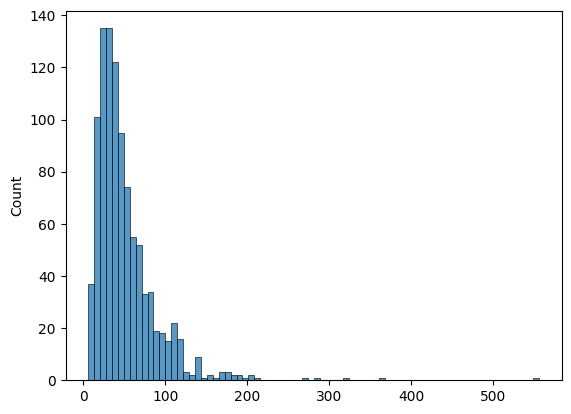

In [151]:
# defining wage distribution
wages = list(wage_dist.rvs(size=1000))


sns.histplot(wages)

wage_dist.rvs()

<Axes: ylabel='Count'>

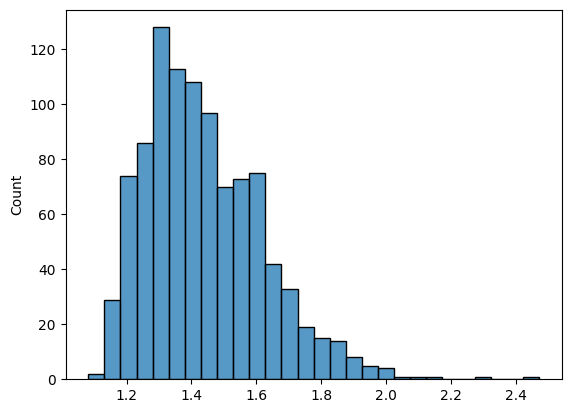

In [ ]:
from scipy.stats import skewnorm

exp_weights = list(exp_weight_bus_dist.rvs(size=1000))
sns.histplot(exp_weights)

#sns.ecdfplot(exp_weights)

#sns.boxplot(exp_weights)